In [120]:
import numpy as np
import matplotlib. pyplot as plt
%matplotlib inline

np.random.seed(seed=1)

X_min = 4
X_max = 30
X_n = 16
X = 5 + 25 * np. random.rand(X_n)

Prm_c = [170, 108, 0.2]
T = Prm_c[0] - Prm_c[1] * np.exp(-Prm_c[2]*X) + 4 * np. random. randn(X_n)

np.savez("week6_data.npz", X=X, X_min=X_min, X_max=X_max, X_n=X_n, T=T)

print(X)

[15.42555012 23.00811234  5.00285937 12.55831432  8.66889727  7.30846487
  9.65650528 13.63901818 14.91918686 18.47041835 15.47986286 22.13048751
 10.11130624 26.95293591  5.68468983 21.76168775]


In [121]:
print(np.round(X,2))

[15.43 23.01  5.   12.56  8.67  7.31  9.66 13.64 14.92 18.47 15.48 22.13
 10.11 26.95  5.68 21.76]


In [122]:
print(np.round(T,2))

[170.91 160.68 129.   159.7  155.46 140.56 153.65 159.43 164.7  169.65
 160.71 173.29 159.31 171.52 138.96 165.87]


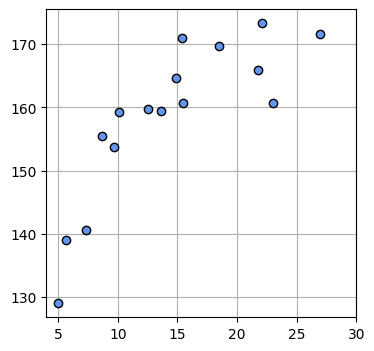

In [123]:
plt.figure(figsize=(4,4))
plt.plot(X,T, marker='o', linestyle='None', markeredgecolor='black',color='cornflowerblue')
plt.xlim(X_min,X_max)
plt.grid(True)
plt.show()

In [124]:
def mes_line(x,t,w):
    y= w[0] * x + w[1]
    mes = np.mean((y-t)**2)
    return mes

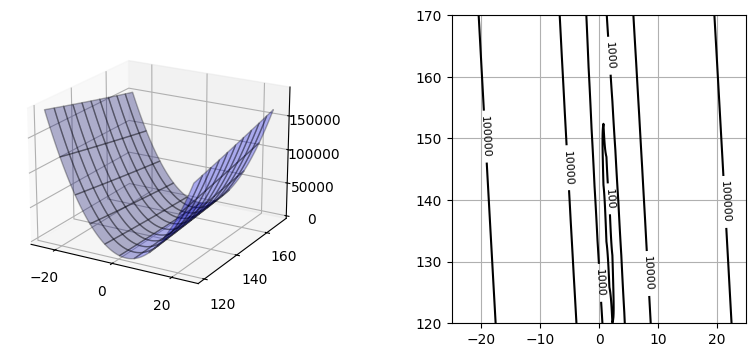

In [125]:
# week5_1.txt
from mpl_toolkits.mplot3d import Axes3D

# 평균 제곱 오차 함수
def mse_line(x, t, w):
    y = w[0] * x + w[1]
    mse = np.mean((y - t) ** 2)
    return mse
    
# 계산
xn = 100 # 등고선 표시 해상도
w0_range = [-25, 25]
w1_range = [120, 170]
x0 = np.linspace(w0_range[0], w0_range[1], xn)
x1 = np.linspace(w1_range[0], w1_range[1], xn)
xx0, xx1 = np.meshgrid(x0, x1)
J = np.zeros((len(x0), len(x1)))

for i0 in range(xn):
    for i1 in range(xn):
        J[i1, i0] = mse_line(X, T, (x0[i0], x1[i1]))
        
# 표시
plt.figure(figsize=(9.5, 4))
plt.subplots_adjust(wspace=0.5)

ax = plt.subplot(1, 2, 1, projection='3d')
ax.plot_surface(xx0, xx1, J, rstride=10, cstride=10, alpha=0.3, 
                color='blue', edgecolor='black')
ax.set_xticks([-20, 0, 20])
ax.set_yticks([120, 140, 160])
ax.view_init(20, -60)

plt.subplot(1,2,2)
cont = plt.contour(xx0, xx1, J, 30, colors='black', 
                   levels=[100, 1000, 10000, 100000])
cont.clabel(fmt='%1.0f', fontsize=8)
plt.grid(True)
plt.show()

In [126]:
def dmse_line(x,t,w):
    y = w[0] * x + w[1]
    d_w0 = 2 * np.mean((y-t)*x)
    d_w1 = 2 * np.mean(y-t)

    return d_w0, d_w1

In [127]:
d_w = dmse_line(X, T, [10, 165])

print(np.round(d_w,1))

[5046.3  301.8]


In [128]:
def fit_line_num(x, t):
    w_init = [10.0, 165.0]

    alpha = 0.001
    i_max = 100000
    eps = 0.1


    w_i = np.zeros((i_max, 2))
    w_i[0, :] = w_init 

    for i in range(1, i_max):
        dmse = dmse_line(x, t, w_i[i - 1])

        w_i[i, 0] = w_i[i - 1, 0] - alpha * dmse[0]
        w_i[i, 1] = w_i[i - 1, 1] - alpha * dmse[1]

        if max(np.absolute(dmse)) < eps:
            break

        w0 = w_i[i, 0]
        w1 = w_i[i, 1]
        w_i_hist = w_i[:i, :]

    return w0, w1, dmse, w_i_hist

In [129]:
W0, W1, dMSE, W_history = fit_line_num(X, T)

print('반복 횟수 {0}'.format(W_history.shape[0]))
print('W=[{:.6f}, {:.6f}]'.format(W0, W1))
print('dMSE=[{:.6f}, {:.6f}]'.format(dMSE[0], dMSE[1]))
print('MSE={:.6f}'.format(mse_line(X, T, [W0, W1])))

반복 횟수 13819
W=[1.539942, 136.176260]
dMSE=[-0.005794, 0.099991]
MSE=49.027462


<Figure size 400x400 with 0 Axes>

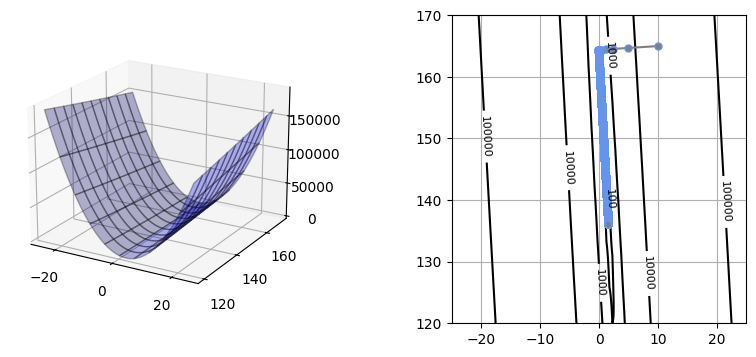

In [130]:
# week5_2.txt
plt.figure(figsize=(4, 4))
xn = 100 # 등고선 표시 해상도
w0_range = [-25, 25]
w1_range = [120, 170]
x0 = np.linspace(w0_range[0], w0_range[1], xn)
x1 = np.linspace(w1_range[0], w1_range[1], xn)
xx0, xx1 = np.meshgrid(x0, x1)
J = np.zeros((len(x0), len(x1)))

for i0 in range(xn):
    for i1 in range(xn):
        J[i1, i0] = mse_line(X, T, (x0[i0], x1[i1]))
        
# 표시
plt.figure(figsize=(9.5, 4))
plt.subplots_adjust(wspace=0.5)

ax = plt.subplot(1, 2, 1, projection='3d')
ax.plot_surface(xx0, xx1, J, rstride=10, cstride=10, alpha=0.3, 
                color='blue', edgecolor='black')
ax.set_xticks([-20, 0, 20])
ax.set_yticks([120, 140, 160])
ax.view_init(20, -60)

plt.subplot(1,2,2)
cont = plt.contour(xx0, xx1, J, 30, colors='black', 
                   levels=[100, 1000, 10000, 100000])
cont.clabel(fmt='%1.0f', fontsize=8)
plt.grid(True)

plt.plot(W_history[:, 0], W_history[:, 1], '.-', color='gray', markersize=10, markeredgecolor='cornflowerblue')
plt.show()

W0=1.540, w1=136.176
mse=49.027 cm^2
SD=7.002 cm


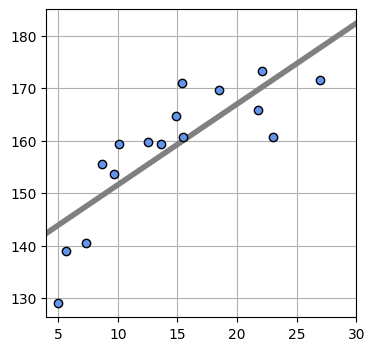

In [131]:
W = np.array([W0, W1])
mse = mse_line(X, T, W)

print("W0={:.3f}, w1={:.3f}".format(W0, W1))
print("mse={:.3f} cm^2".format(mse))
print("SD={:.3f} cm".format(np.sqrt(mse)))

def show_line(w):
    xb = np.linspace(X_min, X_max, 100)
    y = w[0] * xb + w[1]
    plt.plot(xb, y, color=(.5, .5, .5), linewidth=4)

plt.figure(figsize=(4, 4))

show_line(W)

plt.plot(X, T, marker='o', linestyle='None', color='cornflowerblue',
         markeredgecolor='black')
plt.xlim(X_min, X_max)
plt.grid(True)
plt.show()

In [132]:
X0 = X
X0_min = 5
X0_max = 30

np.random.seed(seed=1)
X1 = 23 * (T / 100) ** 2 + 2 * np.random.randn(X_n)
X1_min = 40
X1_max = 75

In [133]:
print("X0=\n", np.round(X0, 2))
print("X1=\n", np.round(X1, 2))
print("T=\n", np.round(T, 2))

X0=
 [15.43 23.01  5.   12.56  8.67  7.31  9.66 13.64 14.92 18.47 15.48 22.13
 10.11 26.95  5.68 21.76]
X1=
 [70.43 58.15 37.22 56.51 57.32 40.84 57.79 56.94 63.03 65.69 62.33 64.95
 57.73 66.89 46.68 61.08]
T=
 [170.91 160.68 129.   159.7  155.46 140.56 153.65 159.43 164.7  169.65
 160.71 173.29 159.31 171.52 138.96 165.87]


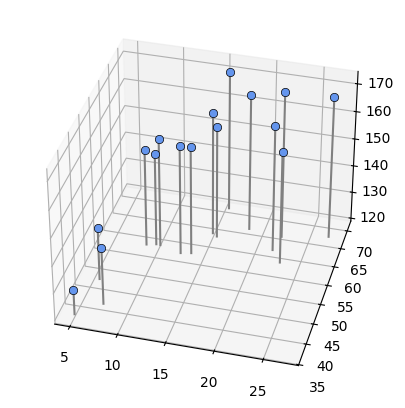

In [134]:
def show_data2(ax, x0, x1, t):
    for i in range(len(x0)):
        ax.plot([x0[i], x0[i]], [x1[i], x1[i]], [120, t[i]], color='gray')
    ax.plot(x0, x1, t, 'o', color='cornflowerblue',
            markeredgecolor='black', markersize=6, markeredgewidth=0.5)
    ax.view_init(elev=35, azim=-75)

plt.figure(figsize=(6, 5))
ax = plt.subplot(1, 1, 1, projection='3d')
show_data2(ax, X0, X1, T)
plt.show()

In [135]:
def mse_plane(x0, x1, t, w):
    y = w[0] * x0 + w[1] * x1 + w[2]
    mse = np.mean((y - t) ** 2)
    return mse

In [136]:
W = [1.5, 1, 90]
mse = mse_plane(X0, X1, T, W)
print("MSE = {:.3f}, SD = {:.3f}cm".format(mse, np.sqrt(mse)))

MSE = 165.789, SD = 12.876cm


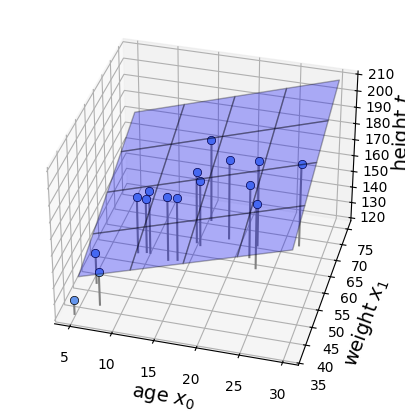

In [137]:
# week5_3.txt
def show_plane(ax, w):
    px0 = np.linspace(X0_min, X0_max, 5)
    px1 = np.linspace(X1_min, X1_max, 5)
    px0, px1 = np.meshgrid(px0, px1)
    y = w[0] * px0 + w[1] * px1 + w[2]
    ax. plot_surface(px0, px1, y, rstride = 1, cstride = 1,
                     alpha = 0.3, color = 'blue', edgecolor = 'black')

plt.figure(figsize = (6, 5))
ax = plt.subplot(1, 1, 1, projection = '3d')
show_plane(ax, W)
show_data2(ax, X0, X1, T) 
ax.set_xlabel('age $x_0$', fontsize = 14)
ax.set_ylabel( 'weight $x_1$', fontsize = 14)
ax.set_zlabel('height $t$', fontsize = 14)

plt.show()

In [138]:
#평균제곱오차 함수
def mse_plane(x0, x1, t, w):
    y = w[0] * x0 + w[1] * x1 + w[2]
    mse = np.mean((y - t) ** 2)
    return mse

In [139]:
#평균제곱오차 함수의 gradient
def dmse_plane(x0, x1, t, w):
    y = w[0] * x0 + w[1] * x1 + w[2]

    d_w0 = 2 * np.mean((y - t) * x0)
    d_w1 = 2 * np.mean((y - t) * x1)
    d_w2 = 2 * np.mean(y - t)

    return np.array([d_w0, d_w1, d_w2])

In [140]:
# 경사하강법을 이용한 면모델 학습
def fit_plane_num(x0, x1, t):
    alpha = 0.0001
    max_iter = 1000000
    eps = 0.05

    w = np.array([0.5, 0.5, 50.0])

    for i in range(max_iter):
        dmse = dmse_plane(x0, x1, t, w)
        w = w - alpha * dmse

        if max(abs(dmse)) < eps:
            break

    return w, i

반복횟수:  950781
MSE =  6.516, SD =  2.553cm


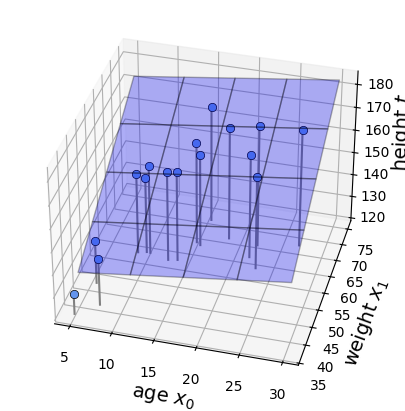

w0 = 0.43449658995556567, w1 = 1.11633070589829, w2 = 87.6060917385778


In [141]:
plt.figure(figsize=(6, 5))
ax = plt.subplot(1, 1, 1, projection='3d')

W, count = fit_plane_num(X0, X1, T)

print("반복횟수: ", count)

mse = mse_plane(X0, X1, T, W)
print("MSE = {0: .3f}, SD = {1: .3f}cm".format(mse, np.sqrt(mse)))

show_plane(ax, W)
show_data2(ax, X0, X1, T)

ax.set_xlabel('age $x_0$', fontsize=14)
ax.set_ylabel('weight $x_1$', fontsize=14)
ax.set_zlabel('height $t$', fontsize=14)

plt.show()

print("w0 = {0}, w1 = {1}, w2 = {2}".format(W[0], W[1], W[2]))

In [ ]:
## 설명 및 문제 해결 과정

# 2차원 특징벡터(age, weight)를 입력으로 사용하여 height를 예측하는 회귀 모델을 구현하였습니다.
# 기존에는 해석해를 이용하여 계산하였으나, 이번 과제에서는 경사하강법을 이용한 수치해 방식으로 동일한 문제를 해결하였습니다.

# 먼저 면모델의 예측식은 다음과 같이 정의하였습니다.

# y = w[0] * x0 + w[1] * x1 + w[2]

# 여기서 x0는 age, x1은 weight, y는 예측된 height를 의미합니다.
    
# w[0], w[1], w[2]는 각각 입력 변수에 대한 가중치와 절편 역할을 수행합니다.
# 즉, 입력 데이터와 실제 height 값의 차이를 최소화하도록 파라미터를 반복적으로 조정하는 방식으로 모델을 학습하였습니다.

# 문제 해결 과정에서는 먼저 모델의 예측 성능을 평가하기 위해 평균제곱오차(MSE)를 계산하는 mse_plane 함수를 구현하였습니다.
# MSE는 예측값과 실제값의 차이를 제곱한 뒤 평균을 계산하는 방식이며, 값이 작을수록 모델의 성능이 우수하다는 의미를 가집니다.

# 이후 경사하강법을 적용하기 위해 오차함수의 gradient를 계산하는 dmse_plane 함수를 구현하였습니다.
# gradient는 현재 파라미터가 오차를 증가시키는 방향을 의미하므로, 경사하강법에서는 gradient의 반대 방향으로 파라미터를 이동시키면서 오차를 감소시킵니다.
# 이를 위해 w[0], w[1], w[2] 각각에 대한 편미분 값을 계산하였습니다.

# 다음 단계에서는 fit_plane_num 함수를 구현하여 경사하강법 학습을 수행하였습니다. 학습 조건은 과제에서 제시된 조건을 그대로 적용하였습니다.

# - learning rate : 0.0001
# - 최대 반복 횟수 : 1,000,000
# - 종료 조건 eps : 0.05
# - 초기 파라미터 : w0 = 0.5, w1 = 0.5, w2 = 50

# 반복문 내부에서는 dmse_plane 함수를 이용하여 gradient를 계산한 후 w = w - alpha * dmse 을 이용하여 파라미터를 갱신하였습니다.


# 학습 결과 950,781회에서 종료 조건을 만족하였으며, 최종적으로 다음과 같은 결과를 얻을 수 있었습니다.

# - MSE ≈ 6.516
# - SD ≈ 2.553cm
# - w0 ≈ 0.434496
# - w1 ≈ 1.116330
# - w2 ≈ 87.606086

# 결과적으로 해석해 방식으로 구한 파라미터와 거의 동일한 결과를 경사하강법 기반 수치해 방식으로 도출할 수 있었으며,
# 이를 통해 경사하강법의 동작 원리와 회귀 모델 학습 과정을 이해할 수 있었습니다.